In [84]:
from pydoc import text

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

In [45]:
path = './data/openpowerlifting-2026-06-20-a9718576.csv'
df = pd.read_csv(path, nrows=5000)

In [46]:
df

,Name,Sex,Event,Equipment,Age,AgeClass,BirthYearClass,Division,BodyweightKg,WeightClassKg,...,Country,State,Federation,ParentFederation,Date,MeetCountry,MeetState,MeetTown,MeetName,Sanctioned
0,E.S. Denisenko,F,B,Raw,28.5,24-34,24-39,Open,67.30,NaN,...,Belarus,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
1,I.S. Lebetskaya,F,B,Raw,43.5,40-44,40-49,Open,73.20,NaN,...,Belarus,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
2,K. Yakimovich,F,B,Raw,26.5,24-34,24-39,Open,60.60,NaN,...,Belarus,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
3,A.G. Golneva,F,B,Raw,19.5,20-23,19-23,Juniors 17-21,50.30,NaN,...,Belarus,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
4,E.V. Marunevskaya,F,B,Raw,19.5,20-23,19-23,Juniors 17-21,63.70,NaN,...,Belarus,NaN,GSF-Belarus,NaN,2019-06-22,Belarus,NaN,Luninets,Bison Power Cup,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Noura Baddour,F,B,Raw,26.0,24-34,24-39,Open,35.53,40,...,Syria,NaN,WPPO,NaN,2011-07-22,Jordan,NaN,Amman,International Powerlifting Competition,Yes
4996,Ibitisam Al Sabea,F,B,Raw,47.0,45-49,40-49,Open,40.12,44,...,Syria,NaN,WPPO,NaN,2011-07-22,Jordan,NaN,Amman,International Powerlifting Competition,Yes
4997,Hiromi Kobayashi,F,B,Raw,42.0,40-44,40-49,Open,43.06,44,...,Japan,NaN,WPPO,NaN,2011-07-22,Jordan,NaN,Amman,International Powerlifting Competition,Yes
4998,Valeria Soledad Gigena,F,B,Raw,28.0,24-34,24-39,Open,41.45,44,...,Argentina,NaN,WPPO,NaN,2011-07-22,Jordan,NaN,Amman,International Powerlifting Competition,Yes


In [47]:
df = df.dropna(subset=['Age'])

(array([   2.,   38.,  751., 1000., 1235.,  803.,  338.,   93.,   19.,
           4.]),
 array([ 0.5,  7.7, 14.9, 22.1, 29.3, 36.5, 43.7, 50.9, 58.1, 65.3, 72.5]),
 <BarContainer object of 10 artists>)

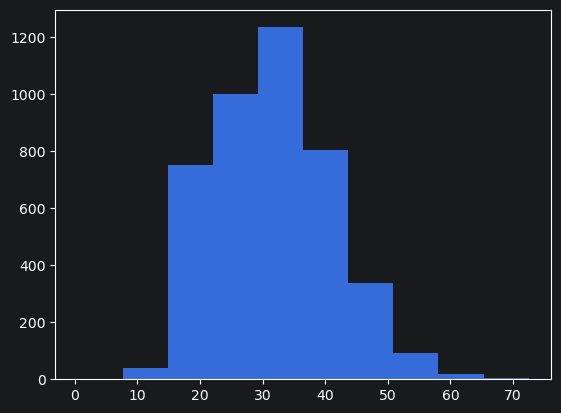

In [48]:
plt.hist(df['Age'])

Mean

$\mu = {\sum x_i \over N}$

Variance

$\sigma^2 = {{\sum{(x_i - \mu)^2}} \over N}$

Standart Deviation


$\sigma = \sqrt{{{\sum{(x_i - \mu)^2}} \over N}}$


In [60]:
df_mean = df.Age.mean()
df_mean

np.float64(31.651412561288815)

In [50]:
# A soma de todos os valores menos a média dos valores sempre resulta em 0
# Como se fosse uma gangorra, quando ela está em 0º o resultado é 0
round(sum(df.Age - df.Age.mean()))

0

In [51]:
sum((df.Age - df.Age.mean())**2)

368677.55895400624

In [59]:
df_variance = sum((df.Age - df.Age.mean())**2) / df.Age.count()
df_variance

np.float64(86.07928063366944)

In [58]:
df_std_deviation = df_variance ** 0.5
df_std_deviation

np.float64(9.277892036107634)

Mean:
$\mu = 31.6$

Variance:
$\sigma^2 = 86.0$

Standart Deviation:
$\sigma = 9.2$


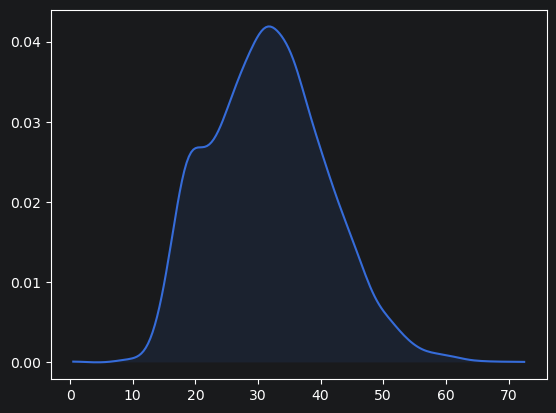

In [85]:
x = np.linspace(df['Age'].min(), df['Age'].max(), 200)
kde = gaussian_kde(df['Age'])(x)

plt.plot(x, kde)
plt.fill_between(x, kde, alpha=0.1)

Text(0.5, 1.0, 'Mean Age')

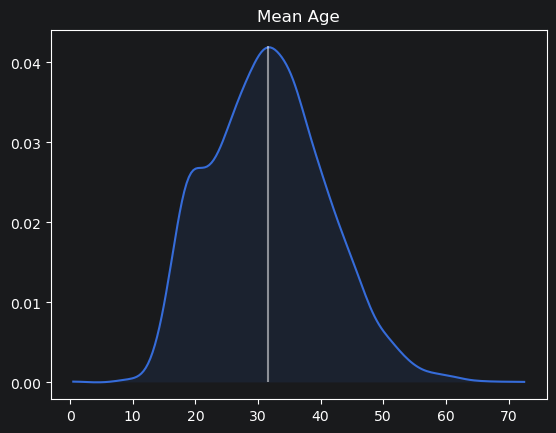

In [125]:
x = np.linspace(df['Age'].min(), df['Age'].max(), 200)
kde = gaussian_kde(df['Age'])(x)

plt.plot(x, kde)
plt.fill_between(x, kde, alpha=0.1)

plt.vlines(x=df_mean, ymin=0, ymax=0.042, colors='white', alpha=0.5)


plt.title('Mean Age')

Text(0.5, 1.0, 'Grid of Standard Deviation of Age')

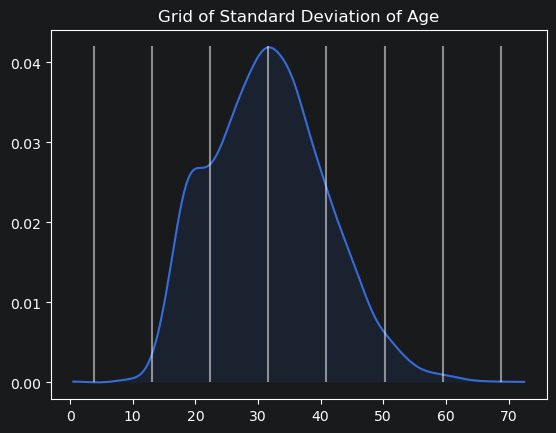

In [123]:
x = np.linspace(df['Age'].min(), df['Age'].max(), 200)
kde = gaussian_kde(df['Age'])(x)

plt.plot(x, kde)
plt.fill_between(x, kde, alpha=0.1)

plt.vlines(x=df_mean, ymin=0, ymax=0.042, colors='white', alpha=0.5)

plt.vlines(x=df_mean + df_std_deviation, ymin=0, ymax=0.042, colors='white', alpha=0.5)
plt.vlines(x=df_mean + df_std_deviation*2, ymin=0, ymax=0.042, colors='white', alpha=0.5)
plt.vlines(x=df_mean + df_std_deviation*3, ymin=0, ymax=0.042, colors='white', alpha=0.5)
plt.vlines(x=df_mean + df_std_deviation*4, ymin=0, ymax=0.042, colors='white', alpha=0.5)

plt.vlines(x=df_mean - df_std_deviation, ymin=0, ymax=0.042, colors='white', alpha=0.5)
plt.vlines(x=df_mean - df_std_deviation*2, ymin=0, ymax=0.042, colors='white', alpha=0.5)
plt.vlines(x=df_mean - df_std_deviation*3, ymin=0, ymax=0.042, colors='white', alpha=0.5)



plt.title('Grid of Standard Deviation of Age')

Empirical Rule

$P(\mu - \sigma \le X \le \mu + \sigma) = {1 \over n}{\sum \mathbb{1} (\mu - \sigma \le x_i \le \mu + \sigma)}$

também conhecida como 68-95-99.7 rule

In [121]:
dentro = df[(df['Age'] >= df_mean - df_std_deviation) & (df['Age'] <= df_mean + df_std_deviation)]
percentual = len(dentro) / len(df) * 100
print(percentual)

64.58090123745038
